In [3]:
import torch
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
MODEL_NAME   = "bert-base-uncased"
MAX_LEN      = 128
BATCH_SIZE   = 32
TRAIN_SAMPLE = None   # use full dataset
EPOCHS       = 3
LR           = 2e-5



df = pd.read_csv("/content/drive/MyDrive/questions.csv").dropna()

df['question1'] = (df['question1'].str.lower()
                                  .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
                                  .str.replace(r"\s+", " ", regex=True)
                                  .str.strip())
df['question2'] = (df['question2'].str.lower()
                                  .str.replace(r"[^a-zA-Z0-9?!\s]", " ", regex=True)
                                  .str.replace(r"\s+", " ", regex=True)
                                  .str.strip())

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")


# ── 4. Dataset ─────────────────────────────────────────────────────
class QuoraDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(
            str(row['question1']),
            str(row['question2']),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'token_type_ids': enc['token_type_ids'].squeeze(),
            'label':          torch.tensor(int(row['is_duplicate']), dtype=torch.long)
        }


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = QuoraDataset(train_df, tokenizer)
test_ds  = QuoraDataset(test_df,  tokenizer)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=2, pin_memory=True
)


Train: 323,478 | Test: 80,870


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


# ── 6. Loss — class-weighted for 60/40 imbalance ──────────────────
neg = (train_df['is_duplicate'] == 0).sum()
pos = (train_df['is_duplicate'] == 1).sum()
weights   = torch.tensor([1.0, neg / pos], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


# ── 7. Optimizer + scheduler ───────────────────────────────────────
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.06 * total_steps),
    num_training_steps=total_steps
)


# ── 8. Train / eval loop ───────────────────────────────────────────
def run_epoch(loader, training=True, epoch=None):
    model.train() if training else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []

    desc = f"Epoch {epoch} — {'Train' if training else 'Val  '}"
    pbar = tqdm(loader, desc=desc, unit="batch", leave=True)

    for batch in pbar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        if training:
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                token_type_ids=token_type_ids)
                loss = criterion(outputs.logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

        else:
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    outputs = model(input_ids=input_ids,
                                    attention_mask=attention_mask,
                                    token_type_ids=token_type_ids)
                    loss = criterion(outputs.logits, labels)

            pbar.set_postfix(loss=f"{loss.item():.4f}")

        total_loss += loss.item()
        preds_all  += outputs.logits.argmax(dim=1).cpu().tolist()
        labels_all += labels.cpu().tolist()

    pbar.close()
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all)
    return total_loss / len(loader), acc, f1


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 109,483,778 / 109,483,778 (100.0%)


In [11]:
print("\nStarting training...\n")
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, training=True,  epoch=epoch)
    ev_loss, ev_acc, ev_f1 = run_epoch(test_loader,  training=False, epoch=epoch)

    print(f"Epoch {epoch}/{EPOCHS}"
          f"  |  train  loss {tr_loss:.4f}  acc {tr_acc:.4f}  f1 {tr_f1:.4f}"
          f"  |  val    loss {ev_loss:.4f}  acc {ev_acc:.4f}  f1 {ev_f1:.4f}")

    if ev_f1 > best_f1:
        best_f1 = ev_f1
        model.save_pretrained("/content/drive/MyDrive/bert-quora-best")
        tokenizer.save_pretrained("/content/drive/MyDrive/bert-quora-best")
        print(f"  ✓ Saved new best model (val F1 = {best_f1:.4f})")


# ── 10. Final evaluation ───────────────────────────────────────────
print("\n── Final results ──────────────────────────────────────────")
_, final_acc, final_f1 = run_epoch(test_loader, training=False, epoch="final")
print(f"Accuracy : {final_acc:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"\nYour LightGBM baseline was: Accuracy 0.8684 | F1 0.8239")
print(f"Improvement: Acc {final_acc - 0.8684:+.4f} | F1 {final_f1 - 0.8239:+.4f}")



Starting training...



Epoch 1 — Val  : 100%|██████████| 1264/1264 [02:33<00:00,  8.23batch/s, loss=0.1159]


Epoch 1/3  |  train  loss 0.3318  acc 0.8471  f1 0.8094  |  val    loss 0.2587  acc 0.8946  f1 0.8633


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved new best model (val F1 = 0.8633)


...

Epoch 3/3  |  train  loss 0.1326  acc 0.9518  f1 0.9366  |  val    loss 0.2938  acc 0.9083  f1 0.8782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved new best model (val F1 = 0.8782)

── Final results ──────────────────────────────────────────


Epoch final — Val  : 100%|██████████| 1264/1264 [02:33<00:00,  8.22batch/s, loss=0.0907]


Accuracy : 0.9083
F1 Score : 0.8782

Your LightGBM baseline was: Accuracy 0.8684 | F1 0.8239
Improvement: Acc +0.0399 | F1 +0.0543


In [8]:
# run this after training — simple inference loop
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Getting predictions"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)

        with torch.amp.autocast('cuda'):
            logits = model(input_ids=input_ids,
                           attention_mask=attention_mask,
                           token_type_ids=token_type_ids).logits

        probs = torch.softmax(logits, dim=1)
        all_preds += probs.argmax(dim=1).cpu().tolist()
        all_probs += probs[:, 1].cpu().tolist()  # prob of being duplicate

# now build the error analysis dataframe
results_df = test_df.copy().reset_index(drop=True)
results_df['predicted']   = all_preds
results_df['confidence']  = all_probs
results_df['correct']     = results_df['predicted'] == results_df['is_duplicate']

fp = results_df[(results_df['predicted']==1) & (results_df['is_duplicate']==0)]
fn = results_df[(results_df['predicted']==0) & (results_df['is_duplicate']==1)]

print("=== False Positives (predicted duplicate, wasn't) ===")
print(fp[['question1','question2','confidence']].head(5).to_string())

print("\n=== False Negatives (predicted not duplicate, was) ===")
print(fn[['question1','question2','confidence']].head(5).to_string())

Getting predictions: 100%|██████████| 1264/1264 [02:42<00:00,  7.77it/s]

=== False Positives (predicted duplicate, wasn't) ===
                                                                                       question1                                              question2  confidence
0   do people realize that you can send marijuana through overnight carriers with zero detection                 how do you send weed through the mail?    0.519531
26                                                    how could we use corroborate in a sentence  how would you use the word corroborate in a sentence?    0.959473
30                                                          is paying for online dating worth it                             is online dating worth it?    0.555176
76                                                                 why do you want to join banks                      why do you want to join our bank?    0.990723
92                                                                          what s google called                           why

In [9]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 1264/1264 [10:44<00:00,  1.96it/s]


In [13]:
def predict(q1, q2):
    model.eval()
    enc = tokenizer(
        q1, q2,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = model(**enc).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return {"duplicate": bool(probs[1] > 0.5), "confidence": float(probs[1])}

print("\n── Inference examples ─────────────────────────────────────")
print(predict("How do I learn Python?",
              "What is the best way to learn Python?"))
print(predict("What is the capital of France?",
              "How do I cook pasta?"))


── Inference examples ─────────────────────────────────────
{'duplicate': True, 'confidence': 0.92333984375}
{'duplicate': False, 'confidence': 0.00017952919006347656}


               precision    recall  f1-score   support

not duplicate       0.94      0.91      0.93     51240
    duplicate       0.86      0.90      0.88     29630

     accuracy                           0.91     80870
    macro avg       0.90      0.91      0.90     80870
 weighted avg       0.91      0.91      0.91     80870



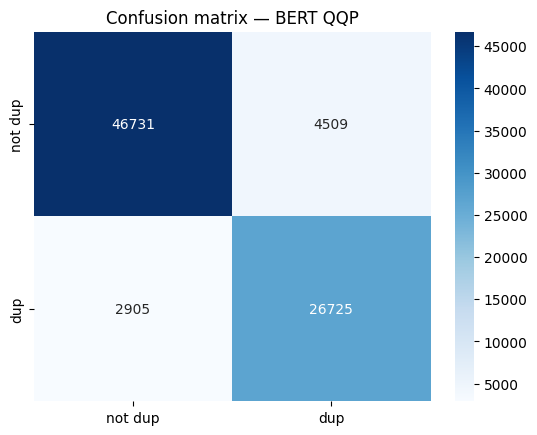

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

# after final eval, collect all_preds and all_labels
print(classification_report(all_labels, all_preds,
      target_names=["not duplicate", "duplicate"]))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["not dup","dup"],
            yticklabels=["not dup","dup"])
plt.title("Confusion matrix — BERT QQP")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')

In [6]:
# Load saved weights instead of training
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/bert-quora-best"
).to(device)
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/bert-quora-best")
model.eval()
print("Loaded saved model ✓")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded saved model ✓


In [11]:
results_df = test_df.copy().reset_index(drop=True)
results_df['pred'] = all_preds
results_df['prob'] = all_probs  # softmax[:,1] from eval loop

fp = results_df[(results_df['is_duplicate']==0) & (results_df['pred']==1)]
fn = results_df[(results_df['is_duplicate']==1) & (results_df['pred']==0)]

fp.sample(50).to_csv("false_positives.csv", index=False)
fn.sample(50).to_csv("false_negatives.csv", index=False)